In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
trend=pd.read_csv("/Users/shivanimittal/Desktop/India_Employement_labour_market/SQL/National_Trend.csv")
trend.head()

,Year,Unemployment_Rate_Pct,Average_Hourly_Earnings_INR
0,2017-18,6.1,50.0
1,2018-19,5.8,53.0
2,2019-20,4.8,56.0
3,2020-21,4.2,59.0
4,2021-22,4.1,66.0


In [4]:
labour=pd.read_csv("/Users/shivanimittal/Desktop/India_Employement_labour_market/SQL/State_Labour_2025.csv")

In [5]:
labour.head()

,Year,State,Region,Age_Group,Area,Sex,Unemployment_Rate_Pct,Worker_Population_Ratio_Pct
0,2025,Andhra Pradesh,South,All ages,Rural,Male,3.8,61.6
1,2025,Andhra Pradesh,South,All ages,Rural,Female,2.8,39.7
2,2025,Andhra Pradesh,South,All ages,Rural,Persons,3.4,50.2
3,2025,Andhra Pradesh,South,All ages,Urban,Male,5.5,55.5
4,2025,Andhra Pradesh,South,All ages,Urban,Female,7.5,24.9


In [6]:
labour.shape

(522, 8)

In [7]:
labour.info()

<class 'pandas.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         522 non-null    int64  
 1   State                        522 non-null    str    
 2   Region                       522 non-null    str    
 3   Age_Group                    522 non-null    str    
 4   Area                         522 non-null    str    
 5   Sex                          522 non-null    str    
 6   Unemployment_Rate_Pct        522 non-null    float64
 7   Worker_Population_Ratio_Pct  522 non-null    float64
dtypes: float64(2), int64(1), str(5)
memory usage: 32.8 KB


In [8]:
labour.describe()

,Year,Unemployment_Rate_Pct,Worker_Population_Ratio_Pct
count,522.0,522.000000,522.000000
mean,2025.0,9.656705,41.705556
std,0.0,8.124799,14.452402
min,2025.0,0.000000,4.600000
25%,2025.0,3.600000,31.600000
50%,2025.0,7.100000,42.400000
75%,2025.0,13.550000,53.600000
max,2025.0,54.200000,74.400000


In [9]:
labour.isnull().sum()

Year                           0
State                          0
Region                         0
Age_Group                      0
Area                           0
Sex                            0
Unemployment_Rate_Pct          0
Worker_Population_Ratio_Pct    0
dtype: int64

In [10]:
trend.isnull().sum()

Year                           0
Unemployment_Rate_Pct          0
Average_Hourly_Earnings_INR    0
dtype: int64

Overall state dataset

In [11]:
overall=labour[
    (labour["Age_Group"]=="All ages") &
    (labour["Area"]=="Rural+Urban") &
    (labour["Sex"]=="Persons")

].copy()

In [12]:
overall.sort_values("Unemployment_Rate_Pct",
                    ascending=False,)

,Year,State,Region,Age_Group,Area,Sex,Unemployment_Rate_Pct,Worker_Population_Ratio_Pct
116,2025,Goa,West,All ages,Rural+Urban,Persons,8.3,39.9
332,2025,Nagaland,Northeast,All ages,Rural+Urban,Persons,6.7,51.2
26,2025,Arunachal Pradesh,Northeast,All ages,Rural+Urban,Persons,6.6,49.5
98,2025,Delhi,North,All ages,Rural+Urban,Persons,5.9,32.8
368,2025,Punjab,North,All ages,Rural+Urban,Persons,5.3,41.4
278,2025,Manipur,Northeast,All ages,Rural+Urban,Persons,5.2,44.2
476,2025,Uttarakhand,North,All ages,Rural+Urban,Persons,5.1,40.5
440,2025,Telangana,South,All ages,Rural+Urban,Persons,5.0,45.2
296,2025,Meghalaya,Northeast,All ages,Rural+Urban,Persons,4.7,42.5
170,2025,Himachal Pradesh,North,All ages,Rural+Urban,Persons,4.5,56.0


Top Unemployment State

In [13]:
top10=overall.sort_values("Unemployment_Rate_Pct",
                          ascending=False,).head(10)

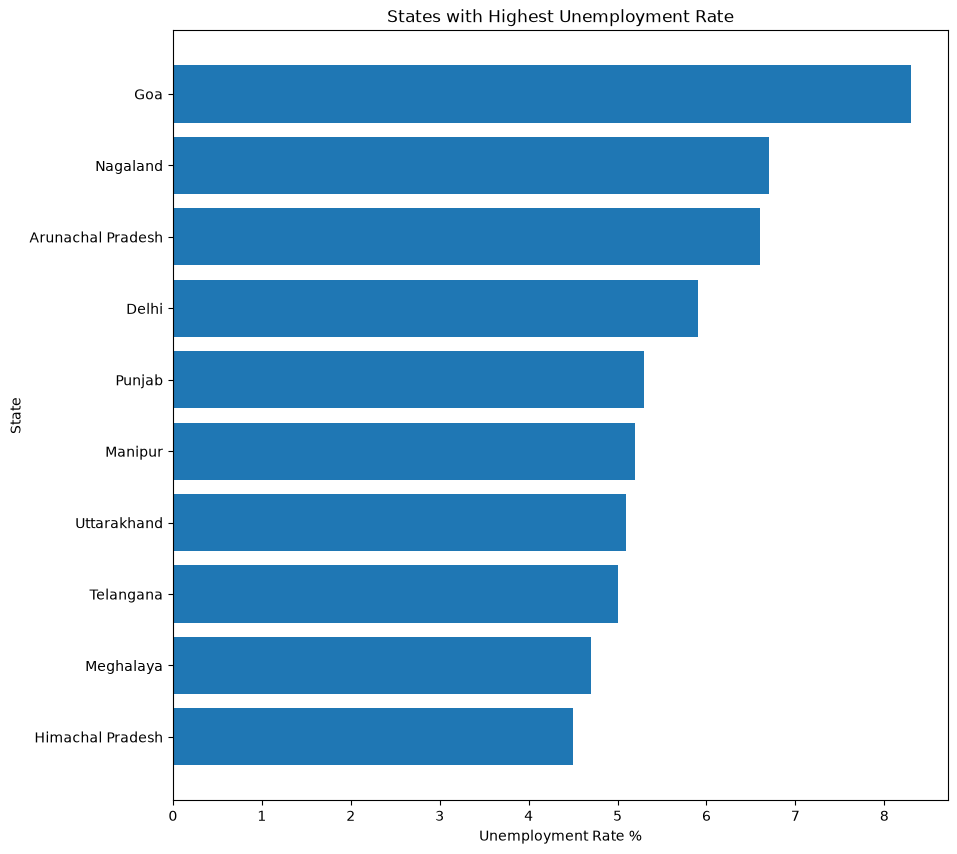

In [14]:
plt.figure(figsize=(10,10))
plt.barh(
    top10["State"],
    top10["Unemployment_Rate_Pct"]

)
plt.xlabel("Unemployment Rate %")
plt.ylabel("State")
plt.title("States with Highest Unemployment Rate")
plt.gca().invert_yaxis()
plt.show()

Youth Unemployment Gap

In [15]:
youth=labour[
    (labour["Age_Group"]=="15-29 years") &
    (labour["Area"]=="Rural+Urban") &
    (labour["Sex"]=="Persons")

].copy()

In [16]:
youth_gap = overall[
    ["State", "Unemployment_Rate_Pct"]
].merge(
    youth[
        ["State", "Unemployment_Rate_Pct"]
    ],
    on="State",
    suffixes=("_Overall", "_Youth")
)

In [17]:
youth_gap["Youth_UR_Gap"] = (
    youth_gap["Unemployment_Rate_Pct_Youth"]
    -
    youth_gap["Unemployment_Rate_Pct_Overall"]
)

In [18]:
youth_gap.sort_values("Youth_UR_Gap",
                      ascending=False)

,State,Unemployment_Rate_Pct_Overall,Unemployment_Rate_Pct_Youth,Youth_UR_Gap
15,Manipur,5.2,22.9,17.7
9,Himachal Pradesh,4.5,19.8,15.3
12,Kerala,4.3,18.2,13.9
1,Arunachal Pradesh,6.6,19.9,13.3
24,Telangana,5.0,18.1,13.1
17,Mizoram,2.4,14.5,12.1
0,Andhra Pradesh,4.2,16.2,12.0
20,Punjab,5.3,17.0,11.7
18,Nagaland,6.7,17.5,10.8
23,Tamil Nadu,3.4,14.1,10.7


Male/Female WPR gap

In [19]:
male = labour[
    (labour["Age_Group"] == "All ages") &
    (labour["Area"] == "Rural+Urban") &
    (labour["Sex"] == "Male")
][
    ["State", "Worker_Population_Ratio_Pct"]
]

In [20]:
female = labour[
    (labour["Age_Group"] == "All ages") &
    (labour["Area"] == "Rural+Urban") &
    (labour["Sex"] == "Female")
][
    ["State", "Worker_Population_Ratio_Pct"]
]

Rural vs Urban

In [21]:
rural_urban = labour[
    (labour["Age_Group"] == "All ages") &
    (labour["Sex"] == "Persons") &
    (labour["Area"].isin(["Rural","Urban"]))
]

In [22]:
area_compare = rural_urban.pivot(
    index="State",
    columns="Area",
    values="Unemployment_Rate_Pct"
)

In [23]:
area_compare["Urban_Rural_Gap"] = (
    area_compare["Urban"]
    -
    area_compare["Rural"]
)

In [24]:
area_compare

Area,Rural,Urban,Urban_Rural_Gap
State,,,
Andhra Pradesh,3.4,6.2,2.8
Arunachal Pradesh,4.9,15.6,10.7
Assam,3.3,6.4,3.1
Bihar,3.0,10.3,7.3
Chhattisgarh,1.8,5.2,3.4
Delhi,3.1,6.0,2.9
Goa,11.9,6.1,-5.8
Gujarat,0.7,1.4,0.7
Haryana,3.5,5.7,2.2


UR vs WPR scatter

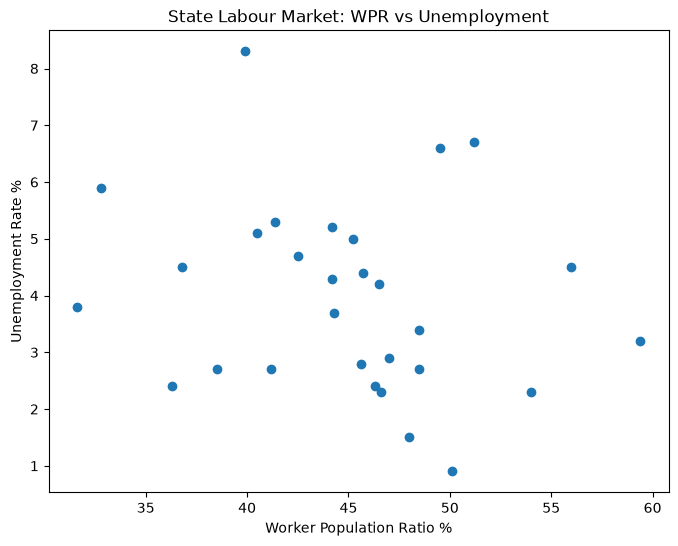

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    overall["Worker_Population_Ratio_Pct"],
    overall["Unemployment_Rate_Pct"]
)

plt.xlabel("Worker Population Ratio %")
plt.ylabel("Unemployment Rate %")
plt.title("State Labour Market: WPR vs Unemployment")

plt.show()

National trend

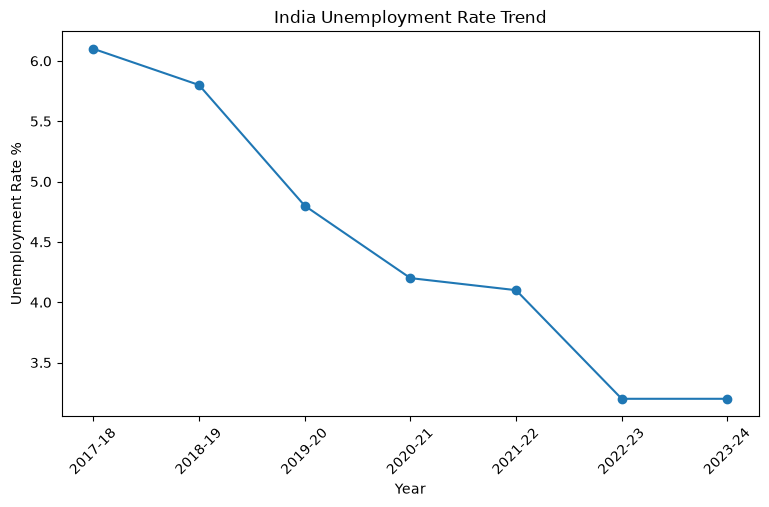

In [26]:
plt.figure(figsize=(9,5))

plt.plot(
    trend["Year"],
    trend["Unemployment_Rate_Pct"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Unemployment Rate %")
plt.title("India Unemployment Rate Trend")

plt.xticks(rotation=45)

plt.show()